In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    HuberRegressor
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [6]:
housing = fetch_california_housing(as_frame = True)

X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

feature_names = X.columns

In [8]:
X_train_cont = X_train_scaled.copy()

np.random.seed(42)

contamination_rate = 0.05
n_contaminated = int(len(X_train_cont) * contamination_rate)

indices = np.random.choice(
    len(X_train_cont),
    n_contaminated,
    replace=False
)

feature = feature_names.get_loc("AveOccup")

X_train_cont[indices, feature] *= 10

In [10]:
feature = feature_names.get_loc("MedInc")

X_train_cont[indices, feature] *= 8

In [13]:
ols = LinearRegression()
ols.fit(X_train_cont, y_train)

ridge = Ridge(alpha = 1.0)
ridge.fit(X_train_cont, y_train)

lasso = Lasso(alpha = 0.01)
lasso.fit(X_train_cont, y_train)

huber = HuberRegressor()
huber.fit(X_train_cont, y_train)

,epsilon,1.35
,max_iter,100
,alpha,0.0001
,warm_start,False
,fit_intercept,True
,tol,1e-05


In [14]:
ols_pred = ols.predict(X_test_scaled)
ridge_pred = ridge.predict(X_test_scaled)
lasso_pred = lasso.predict(X_test_scaled)
huber_pred = huber.predict(X_test_scaled)

In [15]:
ols_rmse = np.sqrt(mean_squared_error(y_test, ols_pred))
ols_mae = mean_absolute_error(y_test, ols_pred)
ols_r2 = r2_score(y_test, ols_pred)

In [16]:
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

In [17]:
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

In [18]:
huber_rmse = np.sqrt(mean_squared_error(y_test, huber_pred))
huber_mae = mean_absolute_error(y_test, huber_pred)
huber_r2 = r2_score(y_test, huber_pred)

In [20]:
metrics_df = pd.DataFrame({
    "Model": ["OLS", "Ridge", "LASSO", "Huber"],
    "RMSE": [
        ols_rmse,
        ridge_rmse,
        lasso_rmse,
        huber_rmse
    ],
    "MAE": [
        ols_mae,
        ridge_mae,
        lasso_mae,
        huber_mae
    ],
    "R²": [
        ols_r2,
        ridge_r2,
        lasso_r2,
        huber_r2
    ]
})

metrics_df = metrics_df.round(4)

metrics_df

,Model,RMSE,MAE,R²
0,OLS,0.8346,0.6331,0.4684
1,Ridge,0.8346,0.6331,0.4684
2,LASSO,0.8363,0.6349,0.4662
3,Huber,0.8290,0.6000,0.4756


In [21]:
metrics_df.to_csv(
    "feature_metrics.csv",
    index=False
)

In [22]:
metrics_df.sort_values("RMSE")

,Model,RMSE,MAE,R²
3,Huber,0.8290,0.6000,0.4756
0,OLS,0.8346,0.6331,0.4684
1,Ridge,0.8346,0.6331,0.4684
2,LASSO,0.8363,0.6349,0.4662


In [23]:
metrics_df.sort_values("MAE")

,Model,RMSE,MAE,R²
3,Huber,0.8290,0.6000,0.4756
0,OLS,0.8346,0.6331,0.4684
1,Ridge,0.8346,0.6331,0.4684
2,LASSO,0.8363,0.6349,0.4662


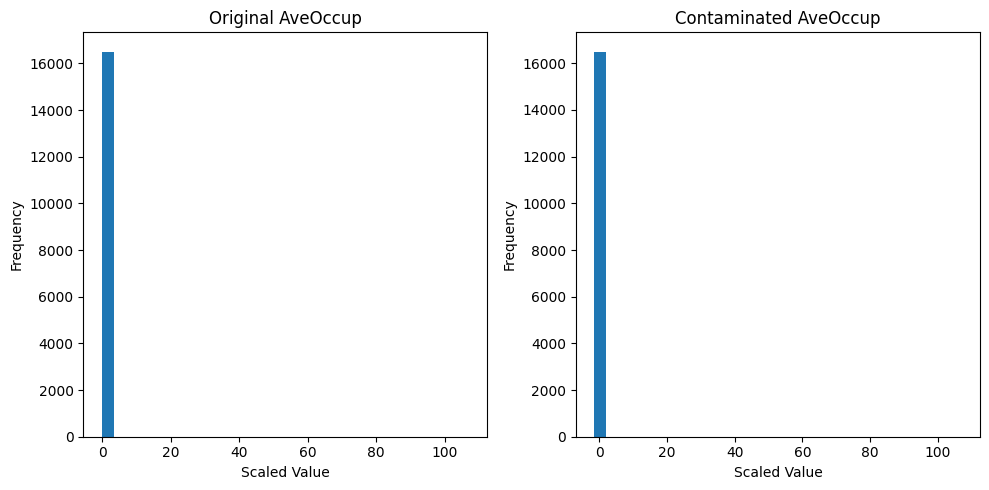

In [24]:
feature = feature_names.get_loc("AveOccup")

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(X_train_scaled[:, feature], bins=30)
plt.title("Original AveOccup")
plt.xlabel("Scaled Value")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(X_train_cont[:, feature], bins=30)
plt.title("Contaminated AveOccup")
plt.xlabel("Scaled Value")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "feature_distribution_before_after.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 1200x600 with 0 Axes>

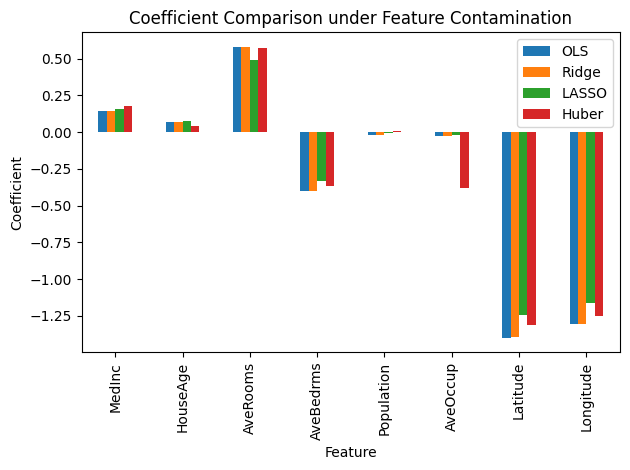

In [25]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "OLS": ols.coef_,
    "Ridge": ridge.coef_,
    "LASSO": lasso.coef_,
    "Huber": huber.coef_
})

coef_df.to_csv(
    "feature_coefficients.csv",
    index=False
)

coef_plot = coef_df.set_index("Feature")

plt.figure(figsize=(12,6))

coef_plot.plot(kind="bar")

plt.ylabel("Coefficient")
plt.title("Coefficient Comparison under Feature Contamination")

plt.tight_layout()

plt.savefig(
    "coefficient_comparison_feature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

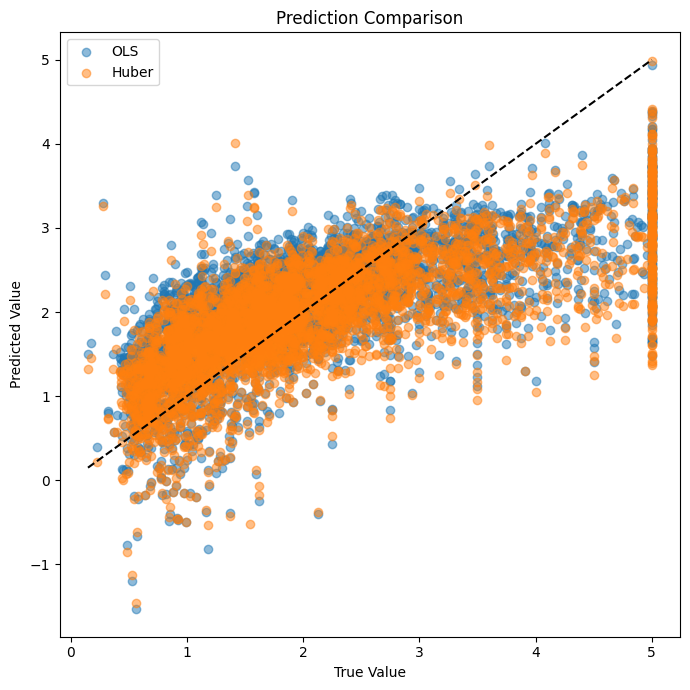

In [26]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    ols_pred,
    alpha=0.5,
    label="OLS"
)

plt.scatter(
    y_test,
    huber_pred,
    alpha=0.5,
    label="Huber"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--'
)

plt.xlabel("True Value")
plt.ylabel("Predicted Value")
plt.title("Prediction Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    "prediction_scatter_feature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

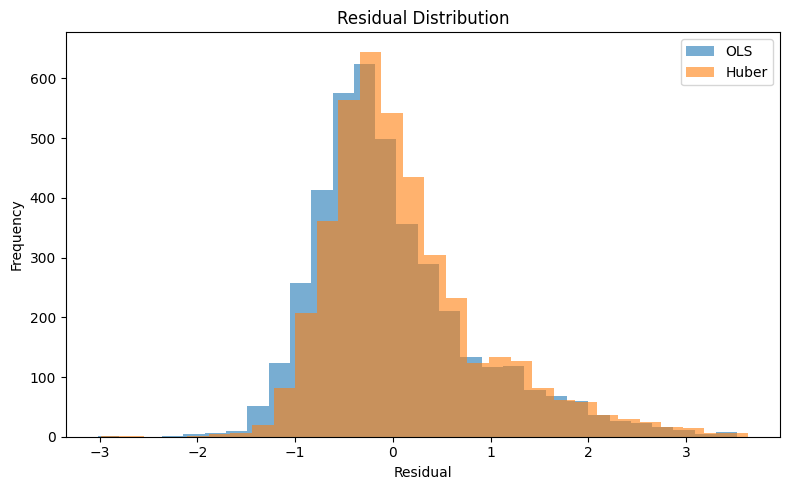

In [27]:
residual_ols = y_test - ols_pred
residual_huber = y_test - huber_pred

plt.figure(figsize=(8,5))

plt.hist(
    residual_ols,
    bins=30,
    alpha=0.6,
    label="OLS"
)

plt.hist(
    residual_huber,
    bins=30,
    alpha=0.6,
    label="Huber"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.legend()

plt.tight_layout()

plt.savefig(
    "residual_distribution_feature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

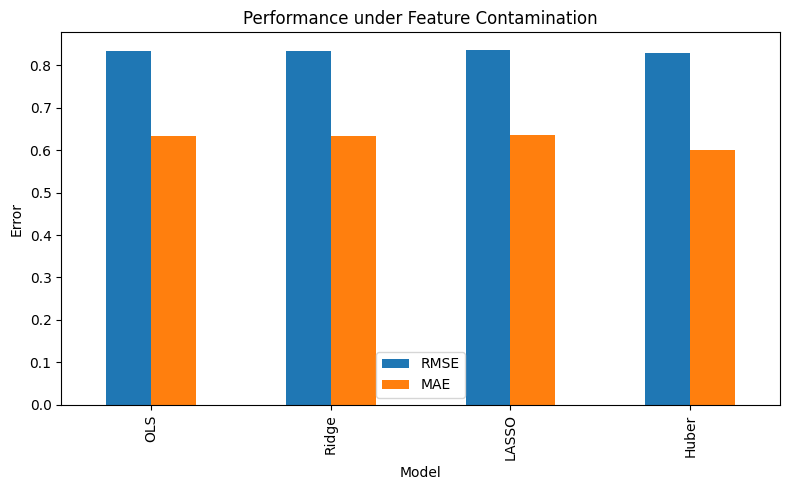

In [28]:
metrics_df.set_index("Model")[["RMSE","MAE"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Performance under Feature Contamination")

plt.ylabel("Error")

plt.tight_layout()

plt.savefig(
    "performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
baseline_coef = pd.read_csv(
    "/Users/dahee/Desktop/Github/robust-regression-comparison/notebooks/baseline_coefficients.csv"
)

feature_coef = pd.read_csv(
    "/Users/dahee/Desktop/Github/robust-regression-comparison/notebooks/feature_coefficients.csv"
)

In [30]:
shift_df = feature_coef.copy()

models = ["OLS","Ridge","LASSO","Huber"]

for model in models:
    shift_df[model] = (
        feature_coef[model]
        - baseline_coef[model]
    )

shift_df.to_csv(
    "feature_shift.csv",
    index=False
)

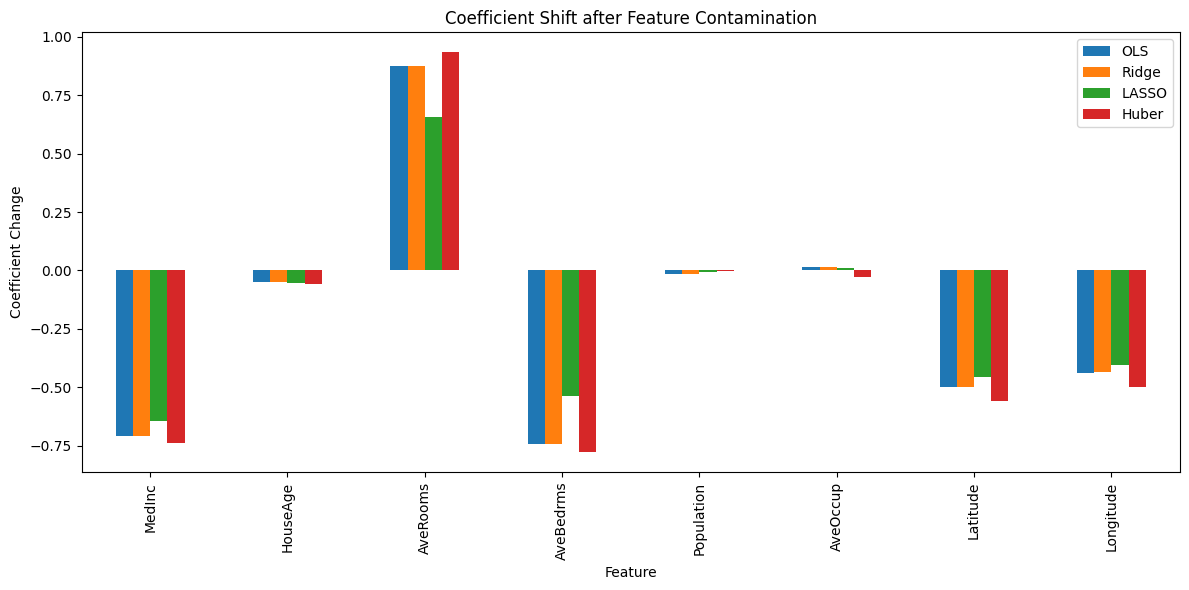

In [31]:
shift_plot = shift_df.set_index("Feature")

shift_plot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.ylabel("Coefficient Change")

plt.title("Coefficient Shift after Feature Contamination")

plt.tight_layout()

plt.savefig(
    "coefficient_shift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()